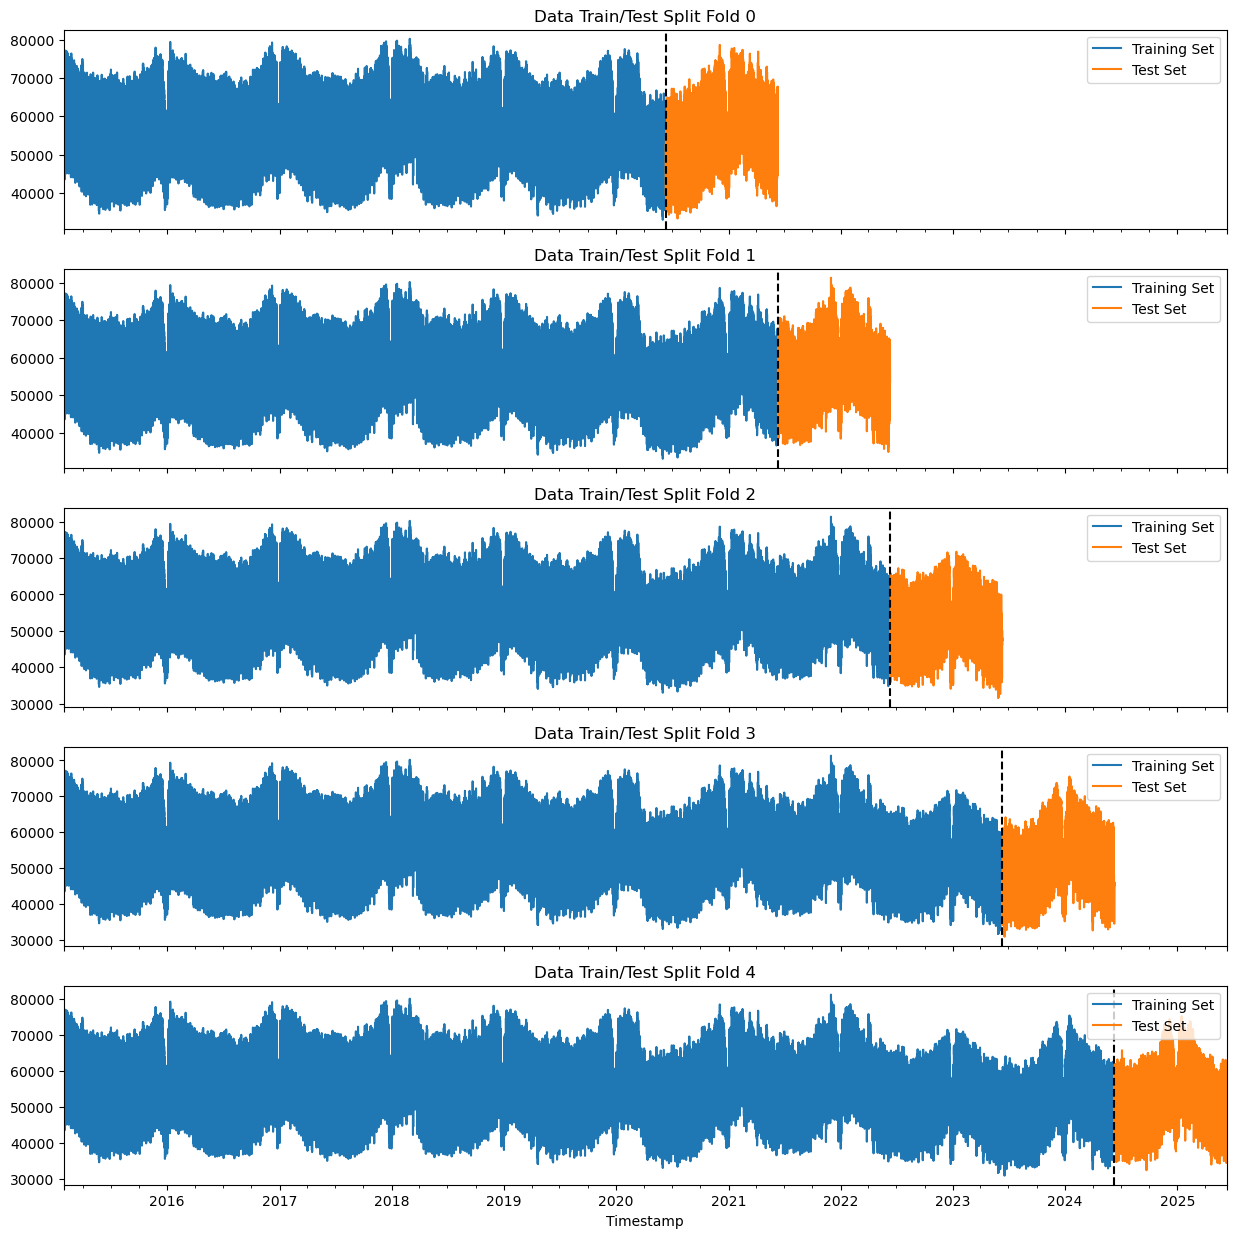

In [32]:
# Time Series Cross Validation Visualization 
tscv = TimeSeriesSplit(n_splits = 5, test_size = 24*365, gap = 24)
germany_entso_df = germany_entso_df.sort_index()


# Visualize Time Series Validation Split
fig, axs = plt.subplots(5, 1, figsize = (15, 15),
                             sharex =True)
fold = 0
for train_indx, val_indx in tscv.split(germany_entso_df):
    train = germany_entso_df.iloc[train_indx]
    test = germany_entso_df.iloc[val_indx]
    train["electricity_load_MW"].plot(label="Training Set", 
                                      title=f"Data Train/Test Split Fold {fold}", 
                                      ax=axs[fold])
    test["electricity_load_MW"].plot(label="Test Set", 
                                     ax=axs[fold])
    axs[fold].legend(["Training Set", "Test Set"], loc="upper right")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1
plt.show()    

In [33]:
# Train Using Cross Validation

baseline_scores = []
xgb_scores = []

for train_indx, val_indx in tscv.split(germany_entso_df):
    train = germany_entso_df.iloc[train_indx]
    test = germany_entso_df.iloc[val_indx]
    

    Features = ["hour", "dayofweek", "is_weekend", "quarter", "month", "year", "dayofyear", "electricity_load_lag_1", 
                "electricity_load_lag_24", "electricity_load_lag_48", "electricity_load_lag_168", "electricity_load_lag_720",
                "electricity_load_rolling_24_mean", "electricity_load_rolling_std_24", "electricity_load_rolling_168_mean"]

    Target = "electricity_load_MW"

    X_train = train[Features]
    y_train = train[Target]
    X_test = test[Features]
    y_test = test[Target]
    
    model_xgb = XGBRegressor(
        n_estimators=1000,
        early_stopping_rounds=50,
        learning_rate=0.01,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    )

    model_xgb.fit(X_train, y_train, 
                  eval_set = [(X_train, y_train), (X_test, y_test)], 
                  verbose = 100)
    # Make Predictions
    y_pred_xgb = (model_xgb.predict(X_test)).astype(float)

    # Baseline
    baseline_pred = test["electricity_load_lag_168"]
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_scores.append(baseline_rmse)

    # Model evaluation xgb
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_scores.append(xgb_rmse)
    xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
    xgb_mape = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
    xgb_r2 = r2_score(y_test, y_pred_xgb)

[0]	validation_0-rmse:10015.11189	validation_1-rmse:9751.41533
[100]	validation_0-rmse:3864.93140	validation_1-rmse:3780.34267
[200]	validation_0-rmse:1675.81604	validation_1-rmse:1674.30770
[300]	validation_0-rmse:956.70369	validation_1-rmse:1016.51423
[400]	validation_0-rmse:741.10752	validation_1-rmse:834.63042
[500]	validation_0-rmse:658.25775	validation_1-rmse:767.26783
[600]	validation_0-rmse:605.47061	validation_1-rmse:722.33136
[700]	validation_0-rmse:575.56595	validation_1-rmse:698.84011
[800]	validation_0-rmse:555.63647	validation_1-rmse:682.73391
[900]	validation_0-rmse:539.07600	validation_1-rmse:669.37207
[999]	validation_0-rmse:526.64143	validation_1-rmse:660.11350
[0]	validation_0-rmse:9973.46012	validation_1-rmse:9562.22569
[100]	validation_0-rmse:3852.30223	validation_1-rmse:3690.97188
[200]	validation_0-rmse:1675.21306	validation_1-rmse:1613.71711
[300]	validation_0-rmse:961.46626	validation_1-rmse:954.94233
[400]	validation_0-rmse:746.63192	validation_1-rmse:769.3736

In [34]:
# Calculate the baseline mean square error for the model
print("Baseline RMSE:", np.mean(baseline_scores))
print("RMSE XGBoost:", np.mean(xgb_scores))

Baseline RMSE: 3900.286888948717
RMSE XGBoost: 680.3547303613342


The model beat the baseline by EUR 680! That's a good indicator that it will helpful in electricity load forecasting

In [35]:
# xgb Model evaluation
print("Model Y_xgb_Prediction:", y_pred_xgb)
print("RMSE XGBoost:", xgb_rmse)
print("MAE XGBoost:", xgb_mae)
print("MAPE XGBoost:", xgb_mape)
print("R2 XGBoost:", xgb_r2)

Model Y_xgb_Prediction: [44486.27734375 43783.5546875  41706.26171875 ... 42036.44140625
 44071.1015625  44014.92578125]
RMSE XGBoost: 714.131843660262
MAE XGBoost: 536.5858233447489
MAPE XGBoost: 1.0236104713217757
R2 XGBoost: 0.9937762831963162


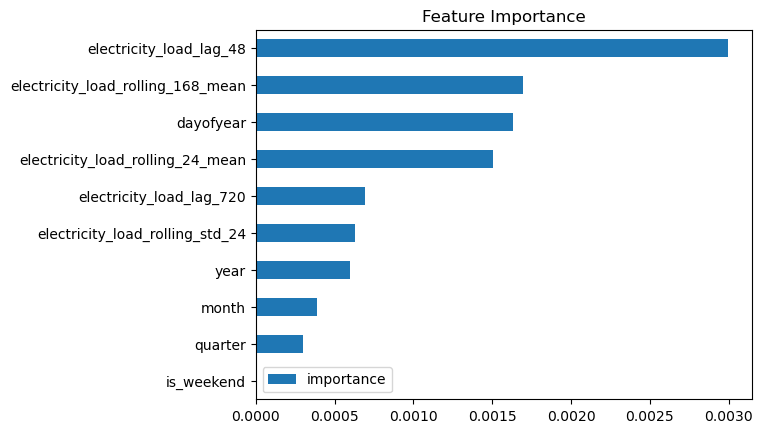

In [36]:
# Feature Importances

feature_import = pd.DataFrame(data=model_xgb.feature_importances_,
             index=model_xgb.feature_names_in_,
             columns=["importance"])

feature_import.sort_values("importance").head(10).plot(kind="barh", title="Feature Importance")
plt.show()

In [37]:
# Create a DataFrame df_predictions that has two columns: "Actual" and "Predicted"
df_predictions = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred_xgb
    }
).round(2)

df_predictions

,Actual,Predicted
Timestamp,,
2024-06-09 21:00:00+02:00,44669.00,44486.28
2024-06-09 22:00:00+02:00,44615.50,43783.55
2024-06-09 23:00:00+02:00,41806.25,41706.26
2024-06-10 00:00:00+02:00,39539.75,39425.43
2024-06-10 01:00:00+02:00,38853.50,38113.92
...,...,...
2025-06-09 16:00:00+02:00,39745.00,39150.94
2025-06-09 17:00:00+02:00,41381.50,40702.14
2025-06-09 18:00:00+02:00,43501.00,42036.44


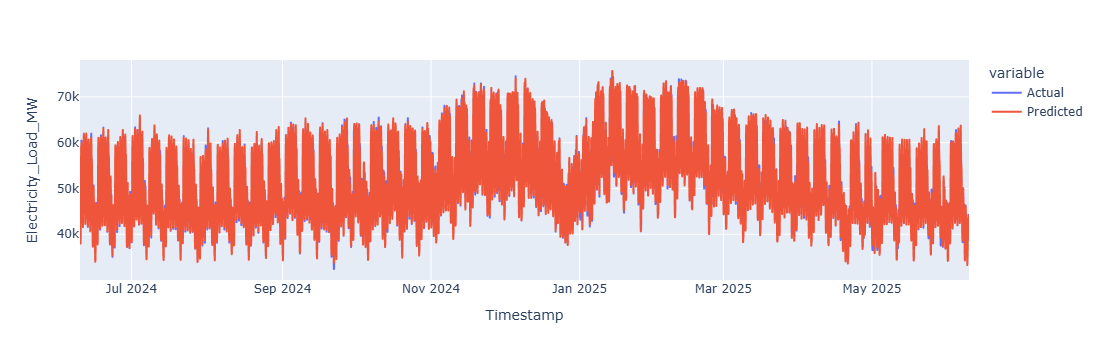

In [38]:
# Visualize a time series line plot for the values of predictions.

fig = px.line(df_predictions, labels={"value": "Electricity_Load_MW"})

fig.show()

In [39]:
# Interactive html plot

fig.write_html("forecast_electricity_load.html")

In [40]:
# Calculate Error

df_predictions["Error"] = df_predictions["Actual"] - df_predictions["Predicted"]
df_predictions

,Actual,Predicted,Error
Timestamp,,,
2024-06-09 21:00:00+02:00,44669.00,44486.28,182.72
2024-06-09 22:00:00+02:00,44615.50,43783.55,831.95
2024-06-09 23:00:00+02:00,41806.25,41706.26,99.99
2024-06-10 00:00:00+02:00,39539.75,39425.43,114.32
2024-06-10 01:00:00+02:00,38853.50,38113.92,739.58
...,...,...,...
2025-06-09 16:00:00+02:00,39745.00,39150.94,594.06
2025-06-09 17:00:00+02:00,41381.50,40702.14,679.36
2025-06-09 18:00:00+02:00,43501.00,42036.44,1464.56


In [41]:
# Save Model
joblib.dump(model_xgb, "electricity_xgb_model.joblib")

['electricity_xgb_model.joblib']

In [42]:
# Load Model 
loaded_model = joblib.load("electricity_xgb_model.joblib")

In [43]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)